In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import drjit as dr
import mitsuba as mi

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject, RadioMaterial

In [2]:
scene = load_scene("universitario.xml",
                   merge_shapes=False) # Disable merging of objects
print("Cena carregada com sucesso!")

Cena carregada com sucesso!


In [3]:
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

Plane          itu_concrete
map_3_osm_buildings-itu_marbleitu_marble
map_3_osm_buildings-itu_metalitu_metal
map_3_osm_paths_cyclewayitu_plasterboard
map_3_osm_paths_footwayitu_plasterboard
map_3_osm_roads_primaryitu_plasterboard
map_3_osm_roads_residentialitu_plasterboard
map_3_osm_roads_secondaryitu_plasterboard
map_3_osm_roads_serviceitu_plasterboard
map_3_osm_roads_tertiaryitu_plasterboard
map_3_osm_roads_unclassifieditu_plasterboard


In [4]:
scene = load_scene("universitario.xml",
                   merge_shapes=True) # Enable merging of objects (default)

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

no-name-1      itu_plasterboard
map_3_osm_buildings-itu_metalitu_metal
map_3_osm_buildings-itu_marbleitu_marble
Plane          itu_concrete


In [5]:
scene = load_scene("universitario.xml",
                   merge_shapes=True, # Enable merging of objects
                   merge_shapes_exclude_regex=r'building_[0-2]$') # Exclude from merging
                                                                  # buildings with indices < 3

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

no-name-2      itu_plasterboard
map_3_osm_buildings-itu_metalitu_metal
map_3_osm_buildings-itu_marbleitu_marble
Plane          itu_concrete


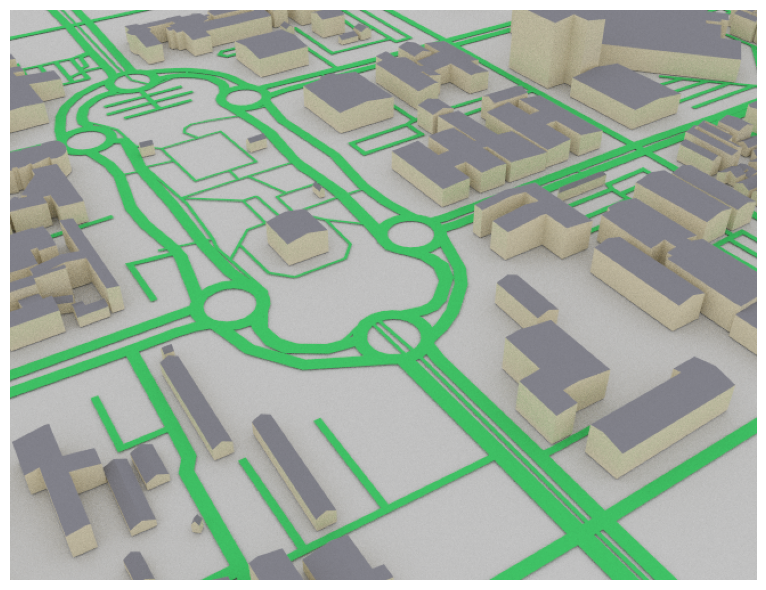

In [6]:
scene = load_scene("universitario.xml") # Objects are merged by default

cam = Camera(position=[484.48,-212.68,328.85], look_at=[83.83,-94.6,-0.0667])
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

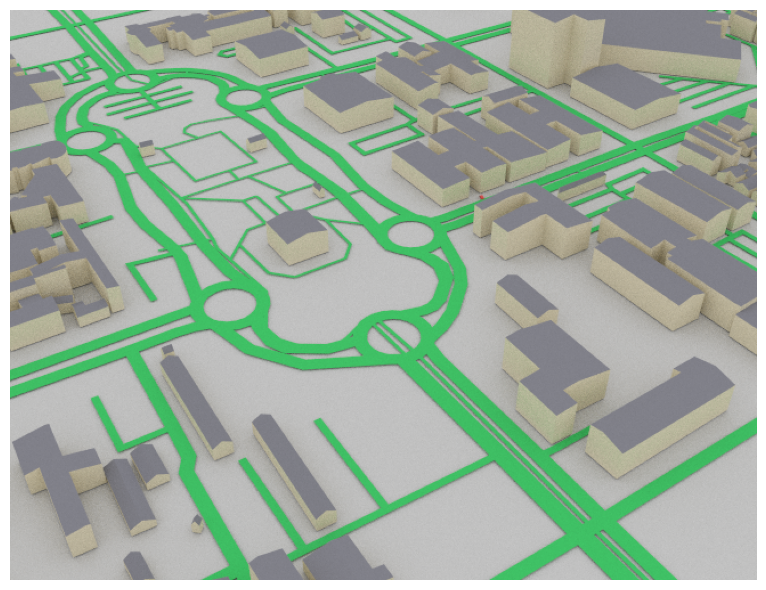

In [7]:
# Number of cars to add
num_cars = 100

# Radio material constituing the cars
# We use ITU metal, and use red color for visualization to
# make the cars easily discernible
car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.01,
                                color=(0.8, 0.1, 0.1))

# Instantiate `num_cars` cars sharing the same mesh and material
cars = [SceneObject(fname=sionna.rt.scene.low_poly_car, # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]

# Add the list of newly instantiated objects to the scene
scene.edit(add=cars)

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

In [8]:
import tensorflow as tf


2025-06-22 20:56:20.455790: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-22 20:56:20.459008: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-22 20:56:20.466883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750636580.481946   37231 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750636580.486478   37231 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750636580.498607   37231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [9]:
all_vertices = [
    (81.9996, -189.7387, 0.3), (86.0529, -196.6359, 0.3), (93.2115, -183.1496, 0.3), 
    (97.1922, -190.0894, 0.3), (106.858, -175.5116, 0.3), (112.1458, -181.7198, 0.3), 
    (126.4275, -150.8139, 0.3), (133.9091, -154.2534, 0.3), (134.9649, -106.8428, 0.3), 
    (142.8182, -108.3676, 0.3), (123.1964, -118.233, 0.3), (115.2373, -119.0406, 0.3), 
    (123.557, -121.7871, 0.3), (115.6018, -122.6332, 0.3), (125.3659, -138.0438, 0.3), 
    (117.2265, -137.2343, 0.3), (117.9132, -161.3834, 0.3), (110.9654, -156.8417, 0.3), 
    (108.7291, -169.4701, 0.3), (104.751, -162.3136, 0.3), (92.5267, -174.3533, 0.3), 
    (91.4789, -166.3136, 0.3), (82.2394, -174.0083, 0.3), (82.5075, -166.0128, 0.3), 
    (-143.3983, 507.2326, 0.3), (-151.0435, 504.8766, 0.3), (-139.8707, 495.7855, 0.3), 
    (-147.5113, 493.4142, 0.3), (-116.4835, 420.9547, 0.3), (-124.1252, 418.5874, 0.3), 
    (-95.824, 353.6636, 0.3), (-103.4717, 351.3156, 0.3), (-92.3688, 342.4092, 0.3), 
    (-100.0165, 340.0613, 0.3), (-83.1653, 312.4296, 0.3), (-90.8138, 310.0843, 0.3), 
    (-75.5616, 287.6048, 0.3), (-83.2105, 285.2607, 0.3), (-55.1756, 221.1227, 0.3), 
    (-62.8599, 218.8942, 0.3), (-32.1895, 137.0852, 0.3), (-39.863, 134.8171, 0.3), 
    (-13.8445, 79.3789, 0.3), (-21.4815, 76.9961, 0.3), (-0.2313, 34.9089, 0.3), 
    (-7.8806, 32.5664, 0.3), (20.4931, -32.7429, 0.3), (12.6852, -34.5675, 0.3), 
    (22.1257, -42.7398, 0.3), (14.2303, -44.0292, 0.3), (-368.2762, 439.0886, 0.3), 
    (-375.9941, 436.9827, 0.3), (-364.928, 426.8175, 0.3), (-372.6236, 424.6301, 0.3), 
    (-342.6609, 351.515, 0.3), (-350.334, 349.2513, 0.3), (-308.7411, 236.269, 0.3), 
    (-316.4062, 233.9779, 0.3), (-257.6548, 67.9299, 0.3), (-265.3281, 65.666, 0.3), 
    (-232.8397, -18.6377, 0.3), (-240.5545, -20.7564, 0.3), (-226.6641, -42.1479, 0.3), 
    (-234.4022, -44.1783, 0.3), (-222.249, -58.9911, 0.3), (-229.9874, -61.0203, 0.3), 
    (-207.4045, -115.5855, 0.3), (-215.1428, -117.6152, 0.3), (-252.4247, -199.853, 0.3), 
    (-246.2172, -194.8064, 0.3), (-257.6286, -193.4519, 0.3), (-250.4614, -189.5859, 0.3), 
    (-260.2463, -185.1869, 0.3), (-252.1733, -184.1808, 0.3), (-259.499, -172.4816, 0.3), 
    (-251.556, -173.6872, 0.3), (-258.3947, -168.0178, 0.3), (-250.8262, -170.737, 0.3), 
    (-254.918, -160.7712, 0.3), (-248.0115, -164.8701, 0.3), (-245.7812, -148.0776, 0.3), 
    (-240.1933, -154.0084, 0.3), (-240.5512, -144.7667, 0.3), (-236.1032, -151.4192, 0.3), 
    (-234.4481, -140.4615, 0.3), (-231.2228, -147.9764, 0.3), (-224.6327, -138.5078, 0.3), 
    (-224.1469, -146.5681, 0.3), (-211.6732, -139.4956, 0.3), (-212.2812, -147.4725, 0.3), 
    (24.8615, -41.4649, 0.3), (32.6729, -39.7381, 0.3), (22.3704, -30.1963, 0.3), 
    (30.1093, -28.1417, 0.3), (2.0097, 35.2888, 0.3), (9.6491, 37.6634, 0.3), 
    (-11.768, 79.6273, 0.3), (-4.1285, 82.002, 0.3), (-29.9014, 137.9409, 0.3), 
    (-22.2523, 140.2844, 0.3), (-55.2526, 221.9413, 0.3), (-47.5975, 224.265, 0.3), 
    (-83.2118, 313.5176, 0.3), (-75.5605, 315.8537, 0.3), (28.7697, -36.5756, 0.3), 
    (28.7647, -44.6275, 0.3), (32.5378, -37.008, 0.3), (31.0109, -44.8853, 0.3), 
    (36.2023, -38.0169, 0.3), (33.1688, -45.4794, 0.3), (42.3561, -41.407, 0.3), 
    (37.4016, -47.8111, 0.3), (47.2786, -46.6131, 0.3), (40.6048, -51.1989, 0.3), 
    (50.378, -53.084, 0.3), (42.624, -55.4146, 0.3), (51.3591, -60.1861, 0.3), 
    (43.2637, -60.0457, 0.3), (50.1356, -67.231, 0.3), (42.4611, -64.667, 0.3), 
    (47.0916, -73.1806, 0.3), (40.4932, -68.5135, 0.3), (42.51, -78.0172, 0.3), 
    (37.5034, -71.6696, 0.3), (36.7354, -81.3482, 0.3), (33.7446, -73.8378, 0.3), 
    (30.2543, -82.8981, 0.3), (29.5194, -74.8483, 0.3), (23.5945, -82.5471, 0.3), 
    (25.1954, -74.6204, 0.3), (17.0956, -80.2049, 0.3), (20.9453, -73.0886, 0.3), 
    (11.5697, -76.0403, 0.3), (17.343, -70.3737, 0.3), (7.5162, -70.4476, 0.3), 
    (14.6997, -66.7269, 0.3), (5.2829, -63.8983, 0.3), (13.2434, -62.4559, 0.3), 
    (5.0762, -56.9808, 0.3), (13.1088, -57.952, 0.3), (6.8976, -50.4127, 0.3), 
    (14.3373, -53.5218, 0.3), (9.2793, -46.2643, 0.3), (15.8159, -50.9465, 0.3), 
    (12.3623, -42.7631, 0.3), (17.8301, -48.6591, 0.3), (16.1625, -39.8943, 0.3), 
    (20.1936, -46.8748, 0.3), (22.2484, -37.3158, 0.3), (24.3022, -45.134, 0.3), 
    (125.9816, -84.5382, 0.3), (132.3938, -79.7545, 0.3), (118.0482, -73.904, 0.3), 
    (124.0331, -68.5477, 0.3), (107.5988, -64.1362, 0.3), (112.4513, -57.7213, 0.3), 
    (85.6485, -50.8735, 0.3), (88.9314, -43.5101, 0.3), (71.4984, -46.5699, 0.3), 
    (72.7751, -38.5964, 0.3), (34.5964, -45.7471, 0.3), (34.7747, -37.7491, 0.3), 
    (43.4225, -63.1689, 0.3), (49.1743, -68.7291, 0.3), (53.3749, -52.8735, 0.3), 
    (58.0754, -59.5214, 0.3), (65.0856, -47.5228, 0.3), (66.3913, -55.7217, 0.3), 
    (79.624, -49.1691, 0.3), (77.0194, -56.9253, 0.3), (99.735, -61.0928, 0.3), 
    (94.5727, -67.3324, 0.3), (106.1285, -68.3297, 0.3), (99.0562, -72.4075, 0.3), 
    (108.5815, -75.6714, 0.3), (100.6127, -77.066, 0.3), (108.9265, -90.0093, 0.3), 
    (100.9288, -90.2018, 0.3), (139.3489, -97.3494, 0.3), (141.7827, -104.9702, 0.3), 
    (144.9365, -95.565, 0.3), (147.3494, -103.1924, 0.3), (217.4392, -72.8465, 0.3), 
    (219.7888, -80.4938, 0.3), (259.4872, -60.1833, 0.3), (261.7928, -67.8439, 0.3), 
    (271.436, -56.5894, 0.3), (273.7523, -64.2468, 0.3), (281.8591, -53.4188, 0.3), 
    (284.1876, -61.0725, 0.3), (348.4439, -33.1597, 0.3), (350.7726, -40.8133, 0.3), 
    (143.3782, -480.1202, 0.3), (141.2675, -472.4037, 0.3), (135.4279, -482.2949, 0.3), 
    (133.265, -474.5926, 0.3), (20.5542, -515.3934, 0.3), (18.339, -507.7062, 0.3), 
    (-45.2288, -534.351, 0.3), (-47.4447, -526.664, 0.3), (-59.475, -538.4587, 0.3), 
    (-61.6914, -530.7718, 0.3), (-198.0645, -113.8748, 0.3), (-190.8069, -110.5092, 0.3), 
    (-206.1388, -96.4631, 0.3), (-198.6218, -93.6568, 0.3), (-217.4002, -57.3607, 0.3), 
    (-209.7124, -55.1475, 0.3), (-222.2311, -40.5736, 0.3), (-214.5432, -38.3608, 0.3), 
    (-253.8642, 69.3054, 0.3), (-246.1915, 71.5711, 0.3), (-304.9337, 238.0028, 0.3), 
    (-297.265, 240.2817, 0.3), (-338.5788, 353.366, 0.3), (-330.9341, 355.7273, 0.3), 
    (-361.6065, 423.9404, 0.3), (-353.9558, 426.283, 0.3), (-366.1911, 439.9515, 0.3), 
    (-358.5002, 442.1537, 0.3), (-209.0338, -119.9832, 0.3), (-214.2386, -113.9078, 0.3), 
    (-219.1785, -128.6741, 0.3), (-223.715, -122.0263, 0.3), (-235.3192, -137.2682, 0.3), 
    (-239.4373, -130.3976, 0.3), (-241.4021, -141.3467, 0.3), (-246.4708, -135.1135, 0.3), 
    (-247.0634, -146.8893, 0.3), (-253.1579, -141.6603, 0.3), (-255.0206, -157.9828, 0.3), 
    (-261.7932, -153.6992, 0.3), (-258.1533, -163.6402, 0.3), (-265.2932, -160.0199, 0.3), 
    (-261.2889, -170.426, 0.3), (-268.8755, -167.7725, 0.3), (-263.3785, -178.9623, 0.3), 
    (-271.2005, -177.2701, 0.3), (-264.5266, -185.0622, 0.3), (-272.4409, -183.8606, 0.3), 
    (-265.5584, -193.971, 0.3), (-273.5416, -193.3641, 0.3), (-265.7556, -199.3771, 0.3), 
    (-273.7496, -199.0676, 0.3), (-265.9265, -203.5494, 0.3), (-273.9198, -203.222, 0.3), 
    (165.7256, -486.3076, 0.3), (171.0646, -492.2654, 0.3), (177.0744, -476.1378, 0.3), 
    (181.1071, -483.2662, 0.3), (373.514, -415.5844, 0.3), (375.6808, -423.2879, 0.3), 
    (431.3463, -400.8552, 0.3), (433.2292, -408.631, 0.3), (444.9138, -397.739, 0.3), 
    (446.7046, -405.536, 0.3), (58.3245, -170.5216, 0.3), (54.5541, -163.4659, 0.3), 
    (36.977, -181.9292, 0.3), (33.78, -174.567, 0.3), (3.6421, -193.2947, 0.3), 
    (1.5544, -185.5544, 0.3), (-0.761, -194.1796, 0.3), (-2.5735, -186.3839, 0.3), 
    (-51.0576, -207.4833, 0.3), (-53.2834, -199.7969, 0.3), (-101.7384, -223.4481, 0.3), 
    (-103.6729, -215.6699, 0.3), (-148.1688, -232.0098, 0.3), (-154.9218, -225.1202, 0.3), 
    (-149.7169, -239.5548, 0.3), (-157.5536, -237.9468, 0.3), (-143.6279, -251.3874, 0.3), 
    (-139.6918, -258.3521, 0.3), (-119.8244, -237.935, 0.3), (-116.5753, -245.2879, 0.3), 
    (-100.7725, -231.6689, 0.3), (-99.0722, -239.5313, 0.3), (-55.9733, -226.8028, 0.3), 
    (-54.2965, -234.6677, 0.3), (-52.8731, -225.8032, 0.3), (-50.4227, -233.4187, 0.3), 
    (-32.9286, -219.3986, 0.3), (-30.0158, -226.8656, 0.3), (-1.53, -204.8791, 0.3), 
    (1.416, -212.3307, 0.3), (5.1026, -202.6823, 0.3), (7.6225, -210.2751, 0.3), 
    (10.3355, -200.942, 0.3), (12.0296, -208.8094, 0.3), (58.3202, -195.9767, 0.3), 
    (59.1437, -203.9342, 0.3), (-190.784, -142.782, 0.3), (-186.7405, -149.6848, 0.3), 
    (-177.3968, -134.94, 0.3), (-173.7884, -142.0977, 0.3), (-174.9209, -133.8815, 0.3), 
    (-171.7855, -141.2415, 0.3), (-135.0008, -116.9354, 0.3), (-132.6663, -124.6353, 0.3), 
    (-86.6305, -107.7675, 0.3), (-84.3593, -115.4795, 0.3), (-35.4975, -87.0166, 0.3), 
    (-33.1205, -94.6857, 0.3), (-30.6147, -85.9473, 0.3), (-28.8537, -93.7512, 0.3), 
    (14.7222, -75.4139, 0.3), (15.982, -83.3343, 0.3), (24.0467, -74.5989, 0.3), 
    (24.7433, -82.5686, 0.3), (-259.1686, -230.8165, 0.3), (-265.9609, -235.0432, 0.3), 
    (-251.8196, -242.6263, 0.3), (-258.1673, -247.5675, 0.3), (-238.7402, -256.2163, 0.3), 
    (-243.6914, -262.6086, 0.3), (-221.1531, -266.1353, 0.3), (-224.2114, -273.5951, 0.3), 
    (-206.744, -270.0395, 0.3), (-207.973, -277.995, 0.3), (-182.5268, -271.0557, 0.3), 
    (-182.327, -279.0711, 0.3), (-166.3394, -269.5661, 0.3), (-165.6064, -277.5325, 0.3), 
    (-177.7949, -257.2739, 0.3), (-179.0402, -249.3714, 0.3), (-183.2883, -258.1396, 0.3), 
    (-185.9806, -250.4651, 0.3), (-188.7263, -261.2422, 0.3), (-191.3128, -253.5074, 0.3), 
    (-198.0847, -262.4365, 0.3), (-198.3552, -254.4061, 0.3), (-206.2124, -261.9517, 0.3), 
    (-205.1566, -254.0004, 0.3), (-218.0731, -259.4926, 0.3), (-214.8792, -251.9847, 0.3), 
    (-230.6483, -250.8896, 0.3), (-225.5723, -244.6693, 0.3), (-236.1294, -245.5866, 0.3), 
    (-229.7099, -240.6661, 0.3), (-244.6722, -230.1707, 0.3), (-237.6748, -226.2931, 0.3), 
    (441.5513, -394.214, 0.3), (439.66, -386.4408, 0.3), (372.1288, -411.1052, 0.3), 
    (370.0071, -403.388, 0.3), (176.7418, -471.1051, 0.3), (175.7881, -463.0293, 0.3), 
    (162.567, -470.2132, 0.3), (163.0694, -462.229, 0.3), (12.4981, -55.4976, 0.3), 
    (8.7368, -48.4369, 0.3), (-11.5617, -68.3144, 0.3), (-14.8065, -60.9787, 0.3), 
    (-32.972, -75.9713, 0.3), (-35.6673, -68.439, 0.3), (-37.7023, -77.665, 0.3), 
    (-39.7666, -69.9068, 0.3), (-84.3676, -85.9768, 0.3), (-86.6011, -78.2487, 0.3), 
    (-148.8608, -112.2191, 0.3), (-151.075, -104.4831, 0.3), (-176.3762, -116.9726, 0.3), 
    (-177.6886, -109.0808, 0.3), (-187.6833, -118.78, 0.3), (-188.946, -110.8803, 0.3), 
    (-273.1562, -217.7366, 0.3), (-275.1355, -209.9853, 0.3), (-325.4719, -231.0956, 0.3), 
    (-327.4514, -223.3444, 0.3), (-393.5122, -248.4729, 0.3), (-395.5857, -240.7457, 0.3), 
    (-400.6988, -250.4949, 0.3), (-402.8803, -242.7981, 0.3), (-468.1834, -269.7632, 0.3), 
    (-470.4608, -262.0938, 0.3), (-497.1268, -278.6904, 0.3), (-499.4847, -271.0457, 0.3), 
    (158.1678, -460.9518, 0.3), (157.4663, -469.019, 0.3), (164.4156, -462.4955, 0.3), 
    (161.2209, -469.9467, 0.3), (169.3297, -465.6304, 0.3), (163.9846, -471.7098, 0.3), 
    (173.0444, -470.0746, 0.3), (166.1134, -474.2566, 0.3), (175.2402, -475.4232, 0.3), 
    (167.3725, -477.3238, 0.3), (175.7281, -481.1821, 0.3), (167.6523, -480.6263, 0.3), 
    (174.4543, -486.826, 0.3), (166.9213, -483.8656, 0.3), (171.5884, -491.7521, 0.3), 
    (165.2018, -486.821, 0.3), (168.5633, -494.761, 0.3), (163.7056, -488.3093, 0.3), 
    (163.1771, -497.7598, 0.3), (160.4542, -490.1195, 0.3), (157.0246, -498.8584, 0.3), 
    (156.8816, -490.7574, 0.3), (151.3264, -498.0472, 0.3), (153.665, -490.2995, 0.3), 
    (146.1652, -495.5865, 0.3), (150.7007, -488.8862, 0.3), (141.9584, -491.7049, 0.3), 
    (148.2961, -486.6674, 0.3), (139.0995, -486.6836, 0.3), (146.655, -483.785, 0.3), 
    (137.8672, -481.0425, 0.3), (145.9467, -480.5428, 0.3), (138.382, -475.4345, 0.3), 
    (146.2637, -477.0894, 0.3), (139.3503, -472.5357, 0.3), (146.7456, -475.6467, 0.3), 
    (140.7296, -469.847, 0.3), (147.4564, -474.2612, 0.3), (143.9077, -465.9765, 0.3), 
    (149.3969, -471.8979, 0.3), (148.119, -463.022, 0.3), (151.8183, -470.1992, 0.3), 
    (152.9561, -461.3106, 0.3), (154.595, -469.2167, 0.3), (85.4475, -167.3745, 0.3), 
    (79.2994, -172.6466, 0.3), (89.4534, -173.8751, 0.3), (81.9476, -176.9441, 0.3), 
    (91.1547, -181.3425, 0.3), (83.0615, -181.8332, 0.3), (90.3686, -188.9563, 0.3), 
    (82.5466, -186.8207, 0.3), (87.5032, -195.2012, 0.3), (80.5493, -191.1734, 0.3), 
    (85.0767, -198.6015, 0.3), (79.0516, -193.2723, 0.3), (82.6541, -200.8235, 0.3), 
    (77.7845, -194.4344, 0.3), (77.3285, -204.1643, 0.3), (74.0246, -196.7931, 0.3), 
    (71.1175, -205.9668, 0.3), (69.9558, -197.9739, 0.3), (64.7395, -206.0065, 0.3), 
    (65.6062, -198.001, 0.3), (60.6506, -205.084, 0.3), (63.0835, -197.4318, 0.3), 
    (56.8614, -203.5098, 0.3), (60.6025, -196.4011, 0.3), (51.5959, -200.0966, 0.3), 
    (57.3157, -194.2705, 0.3), (46.2169, -192.1239, 0.3), (53.652, -188.8403, 0.3), 
    (44.3403, -184.3961, 0.3), (52.4361, -183.8332, 0.3), (45.1267, -176.5098, 0.3), 
    (52.9507, -178.6729, 0.3), (48.5055, -169.3344, 0.3), (55.1597, -173.9816, 0.3), 
    (54.0434, -163.7273, 0.3), (58.8353, -170.2601, 0.3), (60.2192, -160.558, 0.3), 
    (62.8113, -168.2197, 0.3), (67.008, -159.3343, 0.3), (67.2621, -167.4174, 0.3), 
    (73.8498, -160.1279, 0.3), (71.7451, -167.9374, 0.3), (80.1752, -162.8849, 0.3), 
    (75.8915, -169.7447, 0.3), (-254.8702, -192.3495, 0.3), (-254.9899, -200.4399, 0.3), 
    (-248.0333, -193.4891, 0.3), (-250.6086, -201.1702, 0.3), (-241.225, -197.0494, 0.3), 
    (-246.1346, -203.5098, 0.3), (-235.9806, -202.6456, 0.3), (-242.7413, -207.1308, 0.3), 
    (-232.8642, -209.6513, 0.3), (-240.7176, -211.6799, 0.3), (-232.2041, -217.2178, 0.3), 
    (-240.29, -216.5812, 0.3), (-234.0417, -224.5944, 0.3), (-241.4807, -221.3607, 0.3), 
    (-238.1684, -230.9486, 0.3), (-244.1787, -225.5151, 0.3), (-243.6819, -235.3772, 0.3), 
    (-247.7292, -228.3669, 0.3), (-250.2554, -237.9304, 0.3), (-251.9899, -230.0218, 0.3), 
    (-257.2922, -238.3625, 0.3), (-256.5552, -230.3022, 0.3), (-264.1139, -236.6664, 0.3), 
    (-261.0157, -229.1932, 0.3), (-269.741, -233.2756, 0.3), (-264.7728, -226.9292, 0.3), 
    (-272.9697, -230.0427, 0.3), (-266.7693, -224.9301, 0.3), (-275.4752, -226.3352, 0.3), 
    (-268.4014, -222.515, 0.3), (-277.2073, -222.1928, 0.3), (-269.5272, -219.8225, 0.3), 
    (-278.0865, -217.9148, 0.3), (-270.0984, -217.0429, 0.3), (-278.1527, -213.4242, 0.3), 
    (-270.1389, -214.2976, 0.3), (-276.5871, -206.7938, 0.3), (-269.0813, -209.8184, 0.3), 
    (-273.0577, -200.8284, 0.3), (-266.7885, -205.9431, 0.3), (-267.9502, -196.1983, 0.3), 
    (-263.4718, -202.9365, 0.3), (-261.7026, -193.2816, 0.3), (-259.4183, -201.0441, 0.3), 
    (130.7364, -78.4229, 0.3), (127.639, -85.8697, 0.3), (135.2064, -80.9908, 0.3), 
    (130.3776, -87.443, 0.3), (139.5276, -85.1271, 0.3), (133.2437, -90.1863, 0.3), 
    (142.6745, -90.2777, 0.3), (135.2794, -93.5182, 0.3), (144.4021, -96.3416, 0.3), 
    (136.4949, -97.7849, 0.3), (144.6235, -98.9849, 0.3), (136.6148, -99.2159, 0.3), 
    (144.5526, -101.7217, 0.3), (136.579, -100.5979, 0.3), (142.6207, -109.1591, 0.3), 
    (135.1624, -106.0513, 0.3), (140.0718, -113.4551, 0.3), (133.6164, -108.6571, 0.3), 
    (136.7826, -117.0367, 0.3), (131.467, -110.9976, 0.3), (132.8152, -119.8427, 0.3), 
    (128.8868, -112.8224, 0.3), (128.3504, -121.7555, 0.3), (125.9723, -114.0711, 0.3), 
    (123.5912, -122.6979, 0.3), (122.8617, -114.687, 0.3), (118.5598, -122.6281, 0.3), 
    (119.874, -114.6456, 0.3), (110.2431, -119.9414, 0.3), (114.1998, -112.8125, 0.3), 
    (103.5724, -114.3124, 0.3), (109.631, -108.9571, 0.3), (100.965, -110.3137, 0.3), 
    (108.1009, -106.6106, 0.3), (99.2369, -105.9813, 0.3), (107.0138, -103.8853, 0.3), 
    (98.3429, -99.9419, 0.3), (106.4149, -99.8392, 0.3), (99.092, -93.8081, 0.3), 
    (106.9029, -95.8429, 0.3), (101.4398, -88.0669, 0.3), (108.4155, -92.1442, 0.3), 
    (105.6111, -82.7985, 0.3), (111.1543, -88.6852, 0.3), (111.1501, -78.9303, 0.3), 
    (114.7648, -86.1637, 0.3), (117.5602, -76.8258, 0.3), (118.9332, -84.7951, 0.3), 
    (124.3029, -76.664, 0.3), (123.3234, -84.6898, 0.3), (-152.1894, -234.9811, 0.3), 
    (-155.0811, -242.5204, 0.3), (-146.5638, -238.0727, 0.3), (-151.4294, -244.5272, 0.3), 
    (-142.0316, -242.6411, 0.3), (-148.5182, -247.4617, 0.3), (-138.9657, -248.2963, 0.3), 
    (-146.5509, -251.0905, 0.3), (-137.6275, -254.6023, 0.3), (-145.6922, -255.1372, 0.3), 
    (-138.1213, -261.0327, 0.3), (-146.0088, -259.2599, 0.3), (-140.4485, -267.1131, 0.3), 
    (-147.4565, -263.0424, 0.3), (-145.4738, -273.2402, 0.3), (-150.8127, -267.1345, 0.3), 
    (-151.2807, -276.8253, 0.3), (-154.4538, -269.3825, 0.3), (-157.8257, -278.5166, 0.3), 
    (-158.679, -270.4743, 0.3), (-163.9803, -278.2613, 0.3), (-162.7189, -270.3068, 0.3), 
    (-167.384, -277.308, 0.3), (-164.5618, -269.7906, 0.3), (-172.914, -274.6695, 0.3), 
    (-168.2239, -268.0433, 0.3), (-178.7872, -268.7809, 0.3), (-172.0546, -264.2026, 0.3), 
    (-182.1307, -261.0944, 0.3), (-174.1924, -259.2878, 0.3), (-182.4383, -252.8393, 0.3), 
    (-174.3967, -253.8061, 0.3), (-180.8457, -247.2281, 0.3), (-173.4301, -250.4004, 0.3), 
    (-177.9507, -242.3085, 0.3), (-171.5692, -247.2381, 0.3), (-173.9129, -238.256, 0.3), 
    (-168.9743, -244.6337, 0.3), (-168.9896, -235.3675, 0.3), (-165.8145, -242.7799, 0.3), 
    (-163.4945, -233.7943, 0.3), (-162.2883, -241.7704, 0.3), (-157.7795, -233.6722, 0.3), 
    (-158.6192, -241.692, 0.3), (-193.6646, -108.2346, 0.3), (-195.2067, -116.1493, 0.3), 
    (-189.6684, -109.5505, 0.3), (-192.8474, -116.9262, 0.3), (-185.9562, -111.5582, 0.3), 
    (-190.6731, -118.1022, 0.3), (-180.5789, -116.6009, 0.3), (-187.0288, -121.5197, 0.3), 
    (-177.0623, -123.2653, 0.3), (-184.7655, -125.8091, 0.3), (-175.9194, -130.7084, 0.3), 
    (-184.0315, -130.5888, 0.3), (-177.2818, -138.118, 0.3), (-184.9084, -135.3576, 0.3), 
    (-180.9788, -144.6857, 0.3), (-187.2896, -139.5879, 0.3), (-186.6193, -149.6785, 0.3), 
    (-190.9052, -142.7884, 0.3), (-193.6995, -152.5754, 0.3), (-195.4697, -144.656, 0.3), 
    (-201.3326, -152.9685, 0.3), (-200.3772, -144.9087, 0.3), (-208.6665, -150.8005, 0.3), 
    (-205.0933, -143.5145, 0.3), (-214.8512, -146.3433, 0.3), (-209.1032, -140.6248, 0.3), 
    (-219.016, -140.5013, 0.3), (-211.7633, -136.8934, 0.3), (-221.1581, -133.671, 0.3), 
    (-213.1403, -132.5027, 0.3), (-221.0544, -126.5177, 0.3), (-213.0736, -127.9006, 0.3), 
    (-218.7463, -119.7495, 0.3), (-211.5855, -123.5369, 0.3), (-214.6346, -114.2772, 0.3), 
    (-208.6378, -119.6138, 0.3), (-213.7662, -113.4505, 0.3), (-208.7812, -119.7502, 0.3), 
    (-207.883, -109.612, 0.3), (-204.5978, -117.0208, 0.3), (-200.8129, -107.7567, 0.3), 
    (-200.0445, -115.8259, 0.3), (-159.4775, -273.2807, 0.3), (-167.2217, -275.2874, 0.3), 
    (-150.4416, -308.1518, 0.3), (-158.1716, -310.2134, 0.3), (-148.4308, -315.4821, 0.3), 
    (-156.1088, -317.7332, 0.3), (-107.3948, -446.8989, 0.3), (-115.0547, -449.2079, 0.3), 
    (-80.0313, -541.0239, 0.3), (-87.7133, -543.2571, 0.3), (-67.8419, -534.2034, 0.3), 
    (-60.3838, -531.3091, 0.3), (-102.3776, -445.2097, 0.3), (-94.8206, -442.5703, 0.3), 
    (-143.4103, -313.4298, 0.3), (-135.7285, -311.1913, 0.3), (-145.2147, -306.787, 0.3), 
    (-137.5285, -304.5649, 0.3), (-153.4248, -280.0217, 0.3), (-145.2716, -279.3218, 0.3), 
    (-152.1114, -269.6832, 0.3), (-144.1752, -270.6915, 0.3), (419.4802, -4.4031, 0.3), 
    (417.0872, 3.2306, 0.3), (405.6699, -8.7323, 0.3), (403.3421, -1.0781, 0.3), 
    (381.5732, -15.8361, 0.3), (379.2596, -8.1778, 0.3), (346.632, -26.6478, 0.3), 
    (344.2672, -19.0053, 0.3), (69.0202, -200.9092, 0.3), (61.3255, -203.0983, 0.3), 
    (119.5943, -378.6839, 0.3), (111.9265, -380.9675, 0.3), (146.0316, -463.6195, 0.3), 
    (138.3369, -465.8167, 0.3), (147.9641, -471.0469, 0.3), (140.2219, -473.0613, 0.3), 
    (154.1797, -466.6496, 0.3), (161.4544, -463.3212, 0.3), (148.3919, -453.9997, 0.3), 
    (155.8536, -451.08, 0.3), (123.2477, -377.3204, 0.3), (130.9226, -375.0508, 0.3), 
    (87.5737, -242.2308, 0.3), (95.2797, -240.079, 0.3), (79.8427, -215.9818, 0.3), 
    (87.6338, -214.1191, 0.3), (77.9977, -206.0089, 0.3), (86.0025, -205.3013, 0.3), 
    (78.0642, -195.9105, 0.3), (86.064, -195.9632, 0.3), (269.1835, -49.9148, 0.3), 
    (266.9836, -42.2232, 0.3), (226.5531, -62.1078, 0.3), (224.3036, -54.4304, 0.3), 
    (147.302, -85.8847, 0.3), (145.496, -78.0742, 0.3), (133.4411, -88.1639, 0.3), 
    (132.143, -80.2699, 0.3), (-397.3942, -260.9132, 0.3), (-395.35, -268.6476, 0.3), 
    (-329.9506, -243.0883, 0.3), (-327.7494, -250.7812, 0.3), (-326.6667, -242.0761, 0.3), 
    (-324.3152, -249.7227, 0.3), (-302.4277, -234.6394, 0.3), (-300.0774, -242.2864, 0.3), 
    (-293.8232, -231.9902, 0.3), (-291.4709, -239.6366, 0.3), (-282.0818, -228.381, 0.3), 
    (-280.1787, -236.1655, 0.3), (-272.3407, -226.5953, 0.3), (-271.2158, -234.5224, 0.3), 
    (-267.6587, -226.1226, 0.3), (-266.8551, -234.0821, 0.3), (-368.0637, 446.2258, 0.3), 
    (-360.3815, 448.4584, 0.3), (-369.898, 452.5376, 0.3), (-362.2159, 454.7702, 0.3), 
    (-366.1786, 439.9087, 0.3), (-358.5127, 442.1964, 0.3), (-368.0556, 446.1982, 0.3), 
    (-360.3897, 448.486, 0.3), (-490.6077, -289.8271, 0.3), (-488.2373, -297.4678, 0.3), 
    (-397.5573, -260.96, 0.3), (-395.1869, -268.6008, 0.3), (-372.2765, 451.794, 0.3), 
    (-379.907, 449.3908, 0.3), (-370.2396, 445.3264, 0.3), (-377.8701, 442.9232, 0.3), 
    (-370.2399, 445.3275, 0.3), (-377.8697, 442.9221, 0.3), (-368.3203, 439.2383, 0.3), 
    (-375.9501, 436.833, 0.3), (-153.5517, -312.8186, 0.3), (-150.9878, -320.3966, 0.3), 
    (-140.8514, -308.5216, 0.3), (-138.2874, -316.0996, 0.3), (348.4002, -33.1733, 0.3), 
    (350.8163, -40.7997, 0.3), (421.7675, -9.9311, 0.3), (424.1835, -17.5576, 0.3), 
    (346.6005, -26.6575, 0.3), (344.2987, -18.9957, 0.3), (269.2344, -49.8998, 0.3), 
    (266.9327, -42.2381, 0.3), (-83.2207, 313.5472, 0.3), (-75.5516, 315.8241, 0.3), 
    (-115.314, 421.6435, 0.3), (-107.6351, 423.8877, 0.3), (-136.7484, 496.1618, 0.3), 
    (-129.1137, 498.5595, 0.3), (-140.5989, 507.458, 0.3), (-133.0267, 510.0392, 0.3)
]

In [10]:
total_vertices = len(all_vertices)
step = total_vertices // num_cars

selected_vertices = [all_vertices[i] for i in range(0, total_vertices, step)][:num_cars]

In [11]:
import random

# Garantir que temos vértices suficientes para espaçar adequadamente
min_gap = 2  # Distância mínima entre vértices selecionados
selected_indices = []

# Função para selecionar vértices não consecutivos
def select_non_consecutive_vertices(vertices, num_cars, min_gap=2):
    total_vertices = len(vertices)
    selected_indices = []
    
    # Começar com um índice aleatório
    current_index = random.randint(0, min_gap)
    selected_indices.append(current_index)
    
    # Selecionar os próximos vértices com espaçamento mínimo
    for i in range(1, num_cars):
        # Próximo índice deve estar pelo menos min_gap posições à frente
        next_index = current_index + min_gap + random.randint(1, 3)
        
        # Se exceder o limite, fazer wrap-around
        if next_index >= total_vertices:
            next_index = (next_index - total_vertices) + random.randint(0, min_gap)
        
        selected_indices.append(next_index)
        current_index = next_index
    
    return [vertices[i] for i in selected_indices]

# Selecionar vértices não consecutivos
car_positions = select_non_consecutive_vertices(all_vertices, num_cars, min_gap)

print(f"Selecionados {len(car_positions)} posições para os carros")

# Posicionar cada carro
for i, position in enumerate(car_positions):
    cars[i].position = position
    print(f"Carro {i}: posição {position}")

print("Carros posicionados com sucesso!")


Selecionados 100 posições para os carros
Carro 0: posição (93.2115, -183.1496, 0.3)
Carro 1: posição (112.1458, -181.7198, 0.3)
Carro 2: posição (123.1964, -118.233, 0.3)
Carro 3: posição (117.2265, -137.2343, 0.3)
Carro 4: posição (92.5267, -174.3533, 0.3)
Carro 5: posição (82.5075, -166.0128, 0.3)
Carro 6: posição (-147.5113, 493.4142, 0.3)
Carro 7: posição (-103.4717, 351.3156, 0.3)
Carro 8: posição (-83.1653, 312.4296, 0.3)
Carro 9: posição (-55.1756, 221.1227, 0.3)
Carro 10: posição (-21.4815, 76.9961, 0.3)
Carro 11: posição (20.4931, -32.7429, 0.3)
Carro 12: posição (-368.2762, 439.0886, 0.3)
Carro 13: posição (-342.6609, 351.515, 0.3)
Carro 14: posição (-316.4062, 233.9779, 0.3)
Carro 15: posição (-240.5545, -20.7564, 0.3)
Carro 16: posição (-229.9874, -61.0203, 0.3)
Carro 17: posição (-246.2172, -194.8064, 0.3)
Carro 18: posição (-259.499, -172.4816, 0.3)
Carro 19: posição (-248.0115, -164.8701, 0.3)
Carro 20: posição (-234.4481, -140.4615, 0.3)
Carro 21: posição (-211.6732, -1

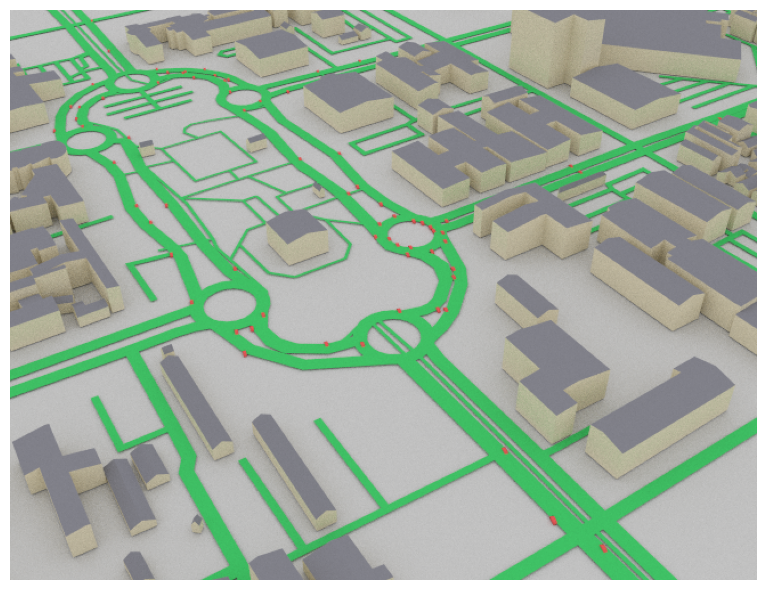

In [12]:
# Renderizar a cena com os carros posicionados
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();


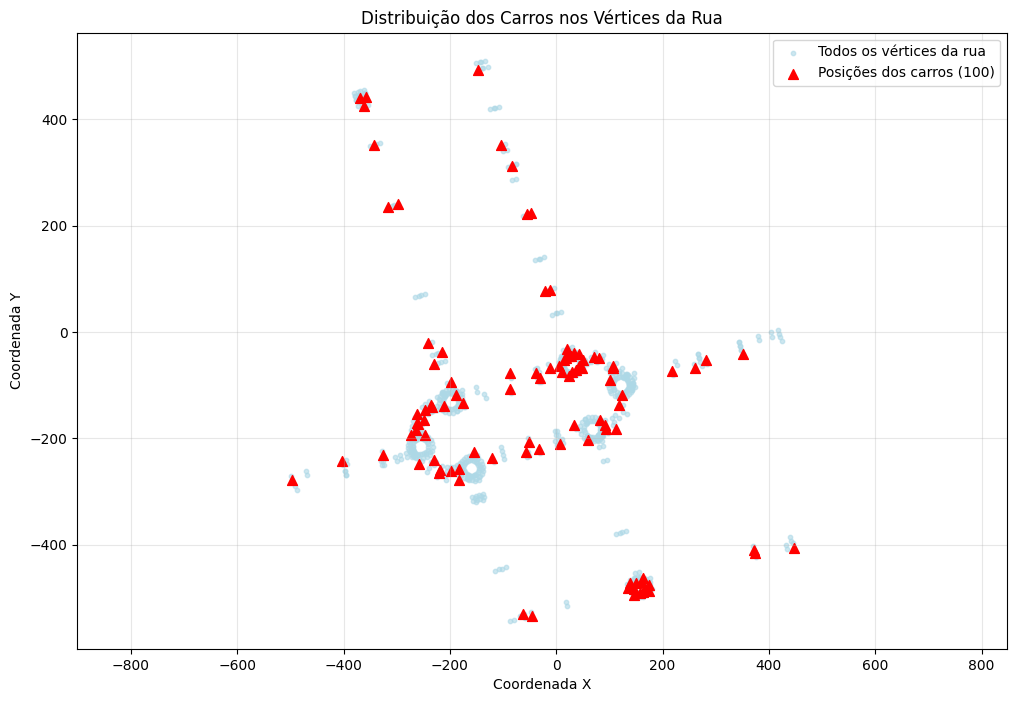

Total de vértices disponíveis: 762
Carros posicionados: 100
Distribuição garantida sem vértices consecutivos (gap mínimo: 2)


In [13]:
# Opcional: Visualizar informações sobre os vértices selecionados
import matplotlib.pyplot as plt
import numpy as np

# Extrair coordenadas x, y de todos os vértices
all_x = [v[0] for v in all_vertices]
all_y = [v[1] for v in all_vertices]

# Extrair coordenadas x, y dos vértices selecionados para os carros
selected_x = [pos[0] for pos in car_positions]
selected_y = [pos[1] for pos in car_positions]

# Criar visualização
plt.figure(figsize=(12, 8))
plt.scatter(all_x, all_y, c='lightblue', s=10, alpha=0.6, label='Todos os vértices da rua')
plt.scatter(selected_x, selected_y, c='red', s=50, marker='^', label=f'Posições dos carros ({num_cars})')

plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Distribuição dos Carros nos Vértices da Rua')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"Total de vértices disponíveis: {len(all_vertices)}")
print(f"Carros posicionados: {len(car_positions)}")
print(f"Distribuição garantida sem vértices consecutivos (gap mínimo: {min_gap})")


In [14]:
# Orientar os carros ao longo da direção da rua
import numpy as np

def calculate_car_orientations_improved(car_positions, all_vertices):
    """
    Calcula orientações dos carros baseado na direção da rua
    Versão melhorada que usa distância euclidiana para encontrar vértices próximos
    """
    orientations = []
    
    for i, car_pos in enumerate(car_positions):
        try:
            # Converter car_pos para numpy array
            car_pos_np = np.array(car_pos[:2])  # Usar apenas x, y para cálculo de direção
            
            # Encontrar os 3 vértices mais próximos
            distances = []
            for j, vertex in enumerate(all_vertices):
                vertex_np = np.array(vertex[:2])
                dist = np.linalg.norm(vertex_np - car_pos_np)
                distances.append((dist, j, vertex))
            
            # Ordenar por distância
            distances.sort(key=lambda x: x[0])
            
            # Pegar os 3 vértices mais próximos
            closest_vertices = distances[:3]
            closest_indices = [x[1] for x in closest_vertices]
            
            # Usar o vértice mais próximo como referência
            car_vertex_idx = closest_indices[0]
            
            # Calcular direção usando vértices próximos na sequência
            total_vertices = len(all_vertices)
            
            # Tentar encontrar uma direção local usando vértices adjacentes
            # Usar vértices a uma distância pequena para ter melhor direção local
            search_range = 5  # Buscar em um range maior
            
            # Vértice anterior
            prev_idx = max(0, car_vertex_idx - search_range)
            prev_vertex = all_vertices[prev_idx]
            
            # Vértice seguinte  
            next_idx = min(total_vertices - 1, car_vertex_idx + search_range)
            next_vertex = all_vertices[next_idx]
            
            # Calcular direção da rua
            direction_vector = np.array(next_vertex[:2]) - np.array(prev_vertex[:2])
            
            # Verificar se a direção é válida
            if np.linalg.norm(direction_vector) < 1e-6:
                # Fallback: usar direção baseada no vértice mais próximo
                if len(closest_vertices) > 1:
                    direction_vector = np.array(closest_vertices[1][2][:2]) - np.array(car_pos[:2])
                else:
                    direction_vector = np.array([1.0, 0.0])  # Direção padrão
            
            # Normalizar
            direction_vector = direction_vector / np.linalg.norm(direction_vector)
            
            # Ponto "look_at" na direção da rua
            look_at_distance = 3.0
            look_at_point_2d = car_pos_np + direction_vector * look_at_distance
            look_at_point = (look_at_point_2d[0], look_at_point_2d[1], car_pos[2])
            
            orientations.append(look_at_point)
            
        except Exception as e:
            print(f"Erro ao calcular orientação para carro {i}: {e}")
            # Fallback: direção padrão
            look_at_point = (car_pos[0] + 2.0, car_pos[1], car_pos[2])
            orientations.append(look_at_point)
    
    return orientations

# Calcular orientações melhoradas
print("Calculando orientações dos carros...")
car_orientations = calculate_car_orientations_improved(car_positions, all_vertices)

# Aplicar orientação aos carros
print("Aplicando orientações...")
for i, (position, look_at_point) in enumerate(zip(car_positions, car_orientations)):
    try:
        # Definir posição do carro
        cars[i].position = mi.Point3f(float(position[0]), float(position[1]), float(position[2]))
        
        # Definir orientação usando look_at
        cars[i].look_at(mi.Point3f(float(look_at_point[0]), float(look_at_point[1]), float(look_at_point[2])))
        
        if i < 5:  # Mostrar apenas os primeiros 5 para não poluir a saída
            print(f"Carro {i}: pos=({position[0]:.2f}, {position[1]:.2f}, {position[2]:.2f}), look_at=({look_at_point[0]:.2f}, {look_at_point[1]:.2f}, {look_at_point[2]:.2f})")
            
    except Exception as e:
        print(f"Erro ao posicionar carro {i}: {e}")

print(f"\nOrientação aplicada a {len(cars)} carros com sucesso!")


Calculando orientações dos carros...
Aplicando orientações...
Carro 0: pos=(93.21, -183.15, 0.30), look_at=(95.69, -181.46, 0.30)
Carro 1: pos=(112.15, -181.72, 0.30), look_at=(113.64, -179.12, 0.30)
Carro 2: pos=(123.20, -118.23, 0.30), look_at=(123.54, -115.25, 0.30)
Carro 3: pos=(117.23, -137.23, 0.30), look_at=(115.79, -139.87, 0.30)
Carro 4: pos=(92.53, -174.35, 0.30), look_at=(91.37, -171.59, 0.30)

Orientação aplicada a 100 carros com sucesso!


Renderizando cena com carros orientados...
Cena renderizada! Os carros agora estão orientados ao longo da direção da rua.


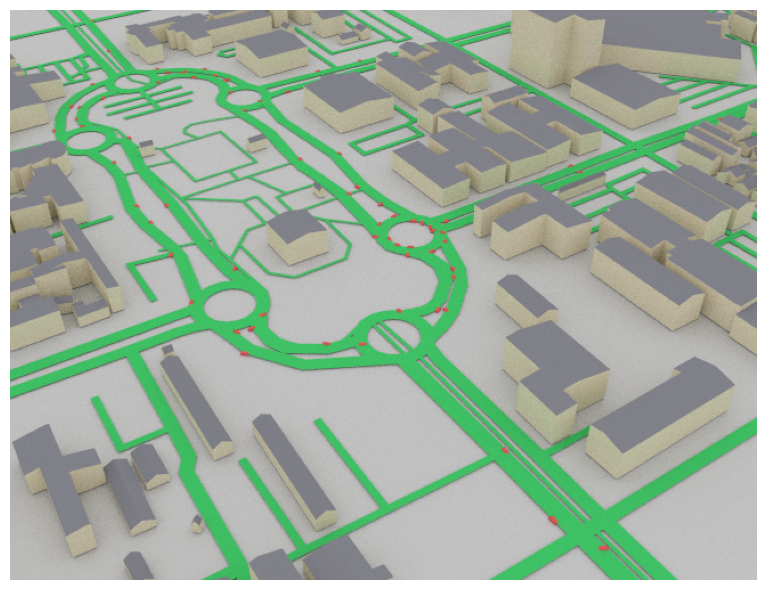

In [15]:
# Renderizar a cena final com carros posicionados e orientados
print("Renderizando cena com carros orientados...")

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();
    
print("Cena renderizada! Os carros agora estão orientados ao longo da direção da rua.")


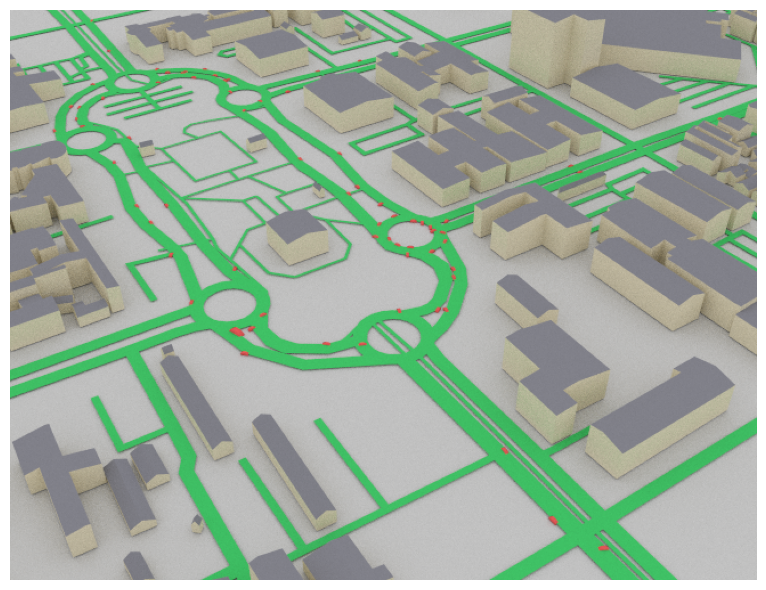

In [16]:
cars[0].scaling = 2.0

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

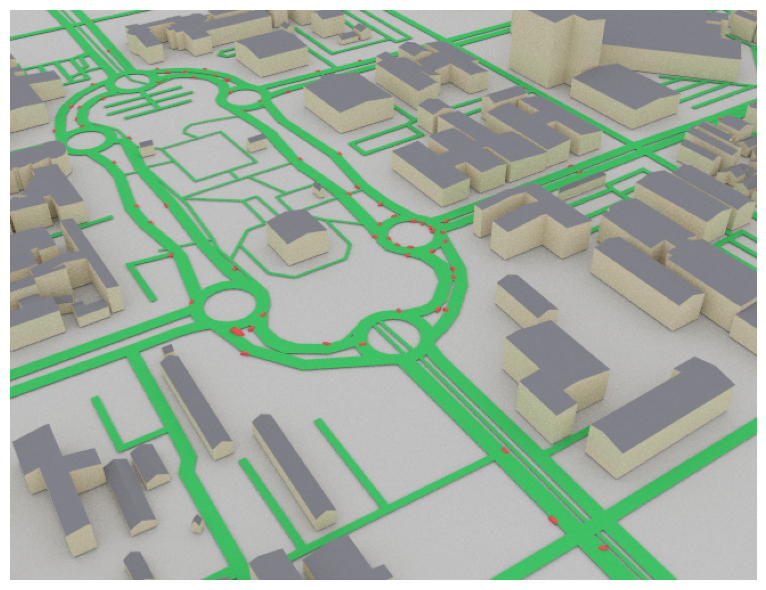

In [17]:
scene.edit(remove=[cars[-1]])

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

In [18]:
# Add a transmitter on top of a building
scene.remove("tx")
scene.add(Transmitter("tx", position=[21.18, -132.4, 18.76], display_radius=2))

# Add a receiver on top of each car
for i in range(num_cars):
    scene.remove(f"rx-{i}")
    scene.add(Receiver(f"rx-{i}", position=[car_positions[i][0],
                                            car_positions[i][1],
                                            car_positions[i][2] + 3],
                      display_radius=2))

# Set the transmit and receive antenna arrays
scene.tx_array = PlanarArray(num_cols=1,
                             num_rows=1,
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

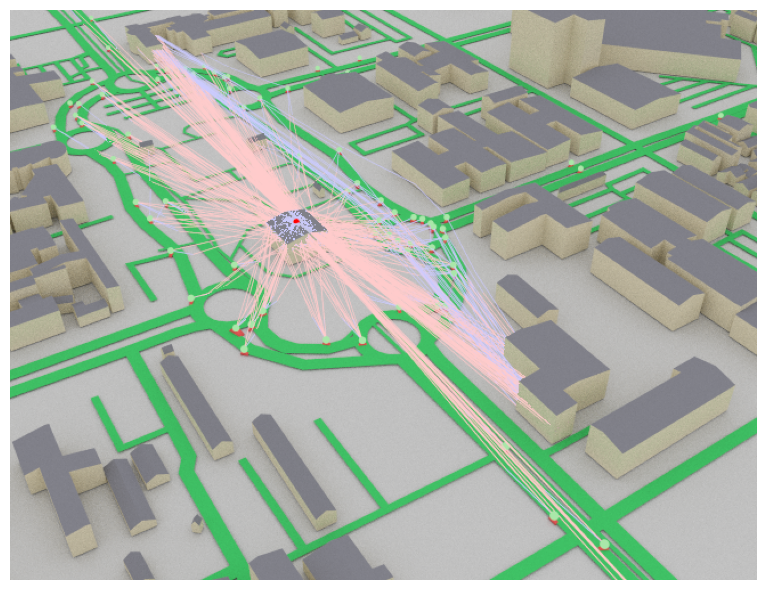

In [19]:
p_solver = PathSolver()
paths = p_solver(scene, max_depth=5)

if no_preview:
    scene.render(camera=cam, paths=paths);
else:
    scene.preview(paths=paths);

In [20]:
print(paths.a)
print(paths.tau)

([[[[[1.80829e-06, 6.24338e-06, -5.94759e-07, -1.33103e-05, 5.62362e-06, 5.74054e-05, 5.75361e-05, -5.80247e-06, 1.5988e-06, 6.04037e-05, 5.07981e-05, 6.18624e-06, -1.47064e-05, 0, 0, 0, 0, 0, 0, 0]]]],
 [[[[7.40503e-06, 6.47642e-06, 4.83164e-05, -3.28929e-06, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]],
 [[[[-5.05389e-06, -1.83592e-06, -1.84089e-05, -5.22533e-06, 6.42125e-06, 1.24207e-05, -1.67222e-05, -4.61709e-06, -1.65932e-06, -2.72221e-06, 3.00519e-06, 5.91491e-06, 3.19478e-05, 0, 0, 0, 0, 0, 0, 0]]]],
 .. 94 skipped ..,
 [[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]],
 [[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]],
 [[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]]], [[[[[1.31149e-06, -3.61947e-06, 3.33496e-07, -4.3612e-06, -3.2533e-06, -9.32446e-06, -8.6629e-06, -5.11085e-06, 1.17239e-06, -8.92149e-06, -8.23158e-06, -3.62765e-06, -4.69151e-06, 0, 0, 0, 0, 0, 0, 0]]]],
 [[[[-2.20211e-06, -2.01125e-06, 4.92506e-06, -

In [21]:
# 1. Acesse os atributos 'a' e 'tau' do objeto 'paths'.
atenuações_tensor = paths.a[0]
atrasos_tensor = paths.tau[0]

# 2. Verifique os shapes DESSES TENSORES para confirmar
print("Shape do tensor de atenuações:", atenuações_tensor.shape)
print("Shape do tensor de atrasos:", atrasos_tensor.shape)

Shape do tensor de atenuações: (100, 1, 1, 1, 20)
Shape do tensor de atrasos: (1, 20)


In [22]:
atenuações_squeezed = tf.squeeze(atenuações_tensor)
print("Shape do tensor de atenuações após squeeze:", atenuações_squeezed.shape)

# Verificação de segurança:
if len(atenuações_squeezed.shape) != 2:
    # Se ainda não for 2D, pode ser que um dos "1" era importante.
    # Neste caso, vamos ser mais específicos:
    atenuações_squeezed = tf.squeeze(atenuações_tensor, axis=[1, 2, 3])
    print("Shape após squeeze específico:", atenuações_squeezed.shape)

Shape do tensor de atenuações após squeeze: (100, 20)


E0000 00:00:1750636624.099270   37231 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1750636624.100889   37231 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [25]:
# 2. Agora, continue com o cálculo do RSS usando o tensor 'squeezed'
# que tem o shape correto (100, 20).

power_per_path = tf.square(tf.abs(atenuações_squeezed))

# Somar as potências ao longo do eixo dos caminhos (axis=1)
# Agora isso funcionará perfeitamente.
total_power_per_rx = tf.reduce_sum(power_per_path, axis=1)

# Converter para dB
epsilon = 1e-10
rss_db_per_rx = 10.0 * tf.math.log(total_power_per_rx + epsilon) / tf.math.log(10.0)

# Imprimir o resultado para verificar
print("\nRSS em dB para cada receptor (para todos os valores):\n", rss_db_per_rx.numpy()[:100])


RSS em dB para cada receptor (para todos os valores):
 [ -78.70407   -85.94812   -86.847855  -84.430305  -79.701866  -80.38556
 -100.       -100.       -100.       -100.       -100.        -99.41119
 -100.       -100.       -100.       -100.       -100.        -93.839455
  -93.84193   -93.440735  -95.35021   -99.87275   -99.24916  -100.
 -100.        -95.78017   -95.82884   -83.9225    -82.47811   -81.64787
  -82.05879   -83.331024  -82.75574   -99.229645  -95.33542   -94.15325
  -84.521935  -85.83892   -82.50171   -91.60391   -85.90017   -85.93651
  -93.04853   -91.78932   -92.8094    -94.82554  -100.       -100.
 -100.        -96.73133  -100.       -100.       -100.       -100.
  -95.35047   -93.12137   -93.19826   -93.75152   -92.82754   -93.06062
 -100.       -100.       -100.        -74.77348   -82.41044   -97.63961
  -88.30433   -83.3131    -81.23942   -82.130875  -92.65389   -99.99852
  -87.286354  -82.733604  -77.7968    -90.789154 -100.        -97.504364
  -90.47225   -90.744

In [26]:
import numpy as np
car_positions_np = np.array(car_positions)

In [27]:
# 2. Crie o vetor de entrada X (posições dos receptores)
# replicando EXATAMENTE a lógica da sua simulação.
X_receptores = np.copy(car_positions_np) # Cria uma cópia para não modificar o original
X_receptores[:, 2] += 3 # Adiciona 3 à coordenada Z (terceira coluna)

# 3. Pegue o seu vetor de saída y (o RSS calculado)
# Supondo que 'rss_db_per_rx' é o tensor com os valores de RSS
y_rss = tf.reshape(rss_db_per_rx, [-1, 1]).numpy()

# Verificação de segurança crucial: os tamanhos devem bater!
# O número de carros/receptores deve ser igual ao número de valores de RSS.
assert len(X_receptores) == len(y_rss), f"Erro de tamanho! Receptores: {len(X_receptores)}, RSS: {len(y_rss)}"


In [28]:
# 4. Salve em um arquivo CSV
import pandas as pd
df_data = pd.DataFrame(X_receptores, columns=['rx_x', 'rx_y', 'rx_z'])
df_data['rss_db'] = y_rss
df_data.to_csv('dataset_rx_e_potencia.csv', index=False)

print("\nDataset de carros criado e salvo com sucesso!")
print("Shape das Entradas (X):", X_receptores.shape)
print("Shape das Saídas (y):", y_rss.shape)


Dataset de carros criado e salvo com sucesso!
Shape das Entradas (X): (100, 3)
Shape das Saídas (y): (100, 1)


In [29]:
df = pd.read_csv('dataset_rx_e_potencia.csv')
X = df[['rx_x', 'rx_y', 'rx_z']].values
y = df[['rss_db']].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [68]:
# Converter TODOS os arrays para float32, que é o padrão do TensorFlow
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train_scaled = y_train_scaled.astype(np.float32)
y_test_scaled = y_test_scaled.astype(np.float32)
# --- FIM DA CORREÇÃO PRINCIPAL ---

print("Tipos de dados verificados e corrigidos para float32.")

Tipos de dados verificados e corrigidos para float32.


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [34]:
baseline_model = Sequential([
    # Camada de entrada: espera vetores de 3 elementos (rx_x, rx_y, rx_z)
    Dense(64, activation='relu', input_shape=(3,)),
    
    # Camadas ocultas
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    
    # Camada de saída: 1 neurônio para prever um único valor (RSS)
    # A ativação 'linear' é o padrão para regressão, então não precisa ser especificada.
    Dense(1) 
])

/home/pedro-kall/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Mostra um resumo da arquitetura do modelo
baseline_model.summary()

# ---------------------------------------------------------------------
# 3. Compilar o Modelo
# ---------------------------------------------------------------------
baseline_model.compile(
    optimizer='adam',
    # Mean Squared Error é uma boa escolha para perda em problemas de regressão.
    loss='mean_squared_error' 
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print("\nIniciando o treinamento do modelo de base...")

# Treinamos com os dados normalizados
history = baseline_model.fit(
    X_train_scaled, 
    y_train_scaled,
    epochs=150,           # Número de vezes que o modelo vê todo o dataset de treino
    batch_size=8,         # Número de amostras por atualização de gradiente
    validation_split=0.2, # Usa 20% dos dados de treino para validação a cada época
    verbose=0             # Define como 0 para não poluir a saída. Mude para 1 se quiser ver o progresso.
)

print("Treinamento concluído!")


Iniciando o treinamento do modelo de base...
Treinamento concluído!


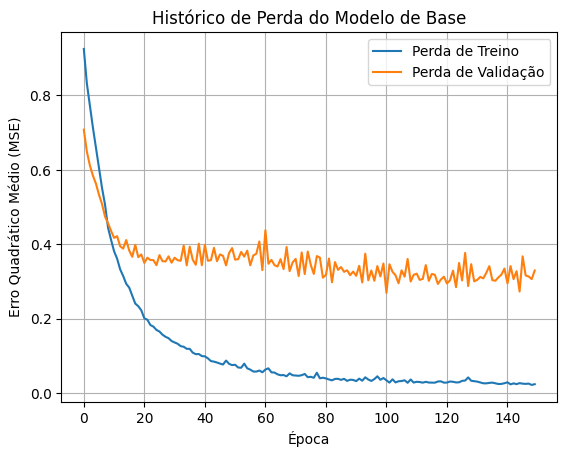

In [37]:
# Visualizar o histórico de treinamento para ver se o modelo aprendeu
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda do Modelo de Base')
plt.xlabel('Época')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Fazer previsões nos dados de teste (que estão na escala normalizada)
predictions_scaled = baseline_model.predict(X_test_scaled)

# As previsões estão na escala NORMALIZADA. Precisamos convertê-las de volta para dBm.
# Usamos o 'scaler_y' que foi ajustado nos dados de treino.
predictions_db = scaler_y.inverse_transform(predictions_scaled)

# Os valores reais de teste (y_test) também precisam estar na escala original.
# (Eles já estão, pois não usamos y_test_scaled para nada ainda)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step



--- Performance do Modelo de Base ---
Erro Absoluto Médio (MAE) no conjunto de teste: 3.39 dB
Isso significa que, em média, as previsões do modelo erram por +/- 3.39 dB.


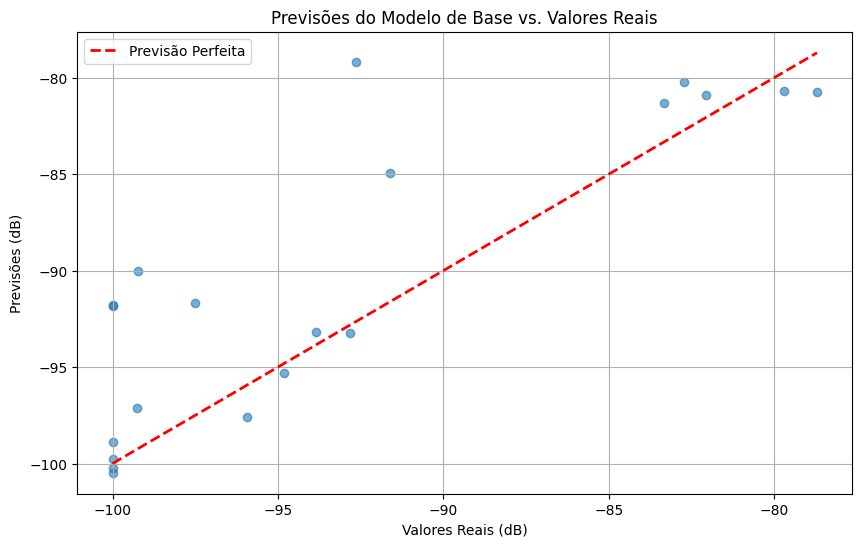

In [39]:
# Esta é uma métrica mais intuitiva que o MSE.
from sklearn.metrics import mean_absolute_error

mae_baseline = mean_absolute_error(y_test, predictions_db)

print(f"\n--- Performance do Modelo de Base ---")
print(f"Erro Absoluto Médio (MAE) no conjunto de teste: {mae_baseline:.2f} dB")
print("Isso significa que, em média, as previsões do modelo erram por +/- {:.2f} dB.".format(mae_baseline))

# Visualizar algumas previsões vs. valores reais
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_db, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Previsão Perfeita')
plt.title('Previsões do Modelo de Base vs. Valores Reais')
plt.xlabel('Valores Reais (dB)')
plt.ylabel('Previsões (dB)')
plt.legend()
plt.grid(True)
plt.show()

### Implementando o PINN

In [61]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [62]:
# Constantes físicas para o cálculo do FSPL
F_HZ = 2.4e9  # Frequência em Hz (ex: 2.4 GHz). AJUSTE SE A SUA FOR DIFERENTE.
C_MPS = 3e8   # Velocidade da luz em m/s

In [63]:
# Posição do transmissor (TX) - PRECISAMOS DISSO PARA CALCULAR A DISTÂNCIA
# Substitua pelas coordenadas reais do seu TX fixo.
TX_POSITION = np.array([21.18, -132.4, 18.76], dtype=np.float32) 

In [69]:
# Usamos os dados de TREINO para criar o dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {"model_input": X_train_scaled, "physics_input": X_train},
        y_train_scaled
    )
).batch(8)

In [91]:
class PhysicsInformedNN(Model):
    """
    Uma implementação de uma Rede Neural Informada pela Física (PINN) para 
    previsão de perda de percurso, inspirada nos princípios teóricos.
    """
    def __init__(self, neural_network, scaler_y, gamma=0.01):
        super().__init__()
        # O modelo base que aprende o mapeamento
        self.nn = neural_network
        
        # Hiperparâmetro para ponderar a perda da física (λ no tutorial)
        self.gamma = tf.constant(gamma, dtype=tf.float32)
        
        # Constantes e ferramentas para o cálculo da física
        self.tx_position_tf = tf.constant(TX_POSITION, dtype=tf.float32)
        self.y_mean_tf = tf.constant(scaler_y.mean_, dtype=tf.float32)
        self.y_scale_tf = tf.constant(scaler_y.scale_, dtype=tf.float32)
        
    def call(self, inputs):
        """Define a passagem para a frente (forward pass) para inferência."""
        return self.nn(inputs["model_input"])

    def _inverse_transform_y(self, y_scaled):
        """Replica a desnormalização do scaler com operações do TensorFlow."""
        return (y_scaled * self.y_scale_tf) + self.y_mean_tf
    
    def _compute_physics_loss(self, rx_positions_original, y_pred_scaled):
        """
        Calcula a perda residual da física (L_física).
        O resíduo é a violação da lei de que RSS_real <= RSS_fspl.
        """
        # Desnormaliza a previsão da rede para a escala de dB
        y_pred_db = self._inverse_transform_y(y_pred_scaled)
        
        # Calcula a distância do TX para cada RX
        distance = tf.norm(self.tx_position_tf - rx_positions_original, axis=1)
        distance = tf.maximum(distance, 1e-6) # Evita log(0)
        
        # Calcula o limite físico (RSS em espaço livre)
        fspl_db = 20. * tf.math.log(distance) / tf.math.log(10.) + \
                  20. * tf.math.log(F_HZ) / tf.math.log(10.) + \
                  20. * tf.math.log(4. * np.pi / C_MPS) / tf.math.log(10.)
        rss_fspl = -fspl_db
        
        # Calcula o resíduo (a violação da lei física)
        # O resíduo é > 0 apenas se y_pred_db > rss_fspl
        residual = tf.nn.relu(tf.reshape(y_pred_db, [-1]) - rss_fspl)
        
        # A perda da física é a média do resíduo (ou do seu quadrado)
        physics_loss = tf.reduce_mean(residual)
        return physics_loss
        
    def train_step(self, data):
        """Define um passo de treinamento customizado."""
        inputs, y_true_scaled = data
        
        with tf.GradientTape() as tape:
            # 1. Previsão da Rede Neural
            y_pred_scaled = self(inputs, training=True)
            
            # 2. Calcular a Perda de Dados (L_dados)
            data_loss = tf.reduce_mean(tf.square(y_true_scaled - y_pred_scaled))
            
            # 3. Calcular a Perda da Física (L_física)
            physics_loss = self._compute_physics_loss(
                rx_positions_original=inputs["physics_input"],
                y_pred_scaled=y_pred_scaled
            )
            
            # 4. Calcular a Perda Total
            total_loss = data_loss + self.gamma * physics_loss

        # Aplicação dos gradientes
        grads = tape.gradient(total_loss, self.nn.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.nn.trainable_variables))
        
        # Atualização das métricas para monitoramento
        self.compiled_metrics.update_state(y_true_scaled, y_pred_scaled)
        # Adicione trackers para as perdas se quiser monitorá-las individualmente
        
        return {m.name: m.result() for m in self.metrics}





In [94]:
pinn_base_model_large = Sequential([
    Dense(128, activation='relu', input_shape=(3,)), # Mais neurônios
    Dense(128, activation='relu'),                  # Mais neurônios
    Dense(64, activation='relu'),                   # Camada extra
    Dense(1)
])

# Instanciar o nosso modelo PINN, passando o scaler_y
# O valor de 'gamma' é um hiperparâmetro. 0.01 é um bom ponto de partida.
pinn_model = PhysicsInformedNN(neural_network=pinn_base_model, scaler_y=scaler_y, gamma=0.1)

pinn_model.compile(optimizer='adam', loss='mean_squared_error') # A perda aqui é apenas para as métricas

print("\nIniciando o treinamento do modelo PINN...")
history_pinn = pinn_model.fit(train_dataset, epochs=300, verbose=1) # verbose=1 para ver o progresso
print("Treinamento do PINN concluído!")



Iniciando o treinamento do modelo PINN...
Epoch 1/300


/home/pedro-kall/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/pedro-kall/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:646: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0323  
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0357
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -0.0077
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0263
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0530
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0134
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0402
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0140    
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0182
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0259
Epoch 13/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046
Epoch 14/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0159
Epoch 15/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0180
Epoch 16/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step



--- Performance do Modelo PINN ---
Erro Absoluto Médio (MAE) no conjunto de teste: 3.84 dB

--- Comparação Final ---
MAE Baseline: 3.39 dB
MAE PINN:     3.84 dB

O modelo PINN não superou o modelo de base. Tente ajustar o gamma ou treinar por mais épocas.


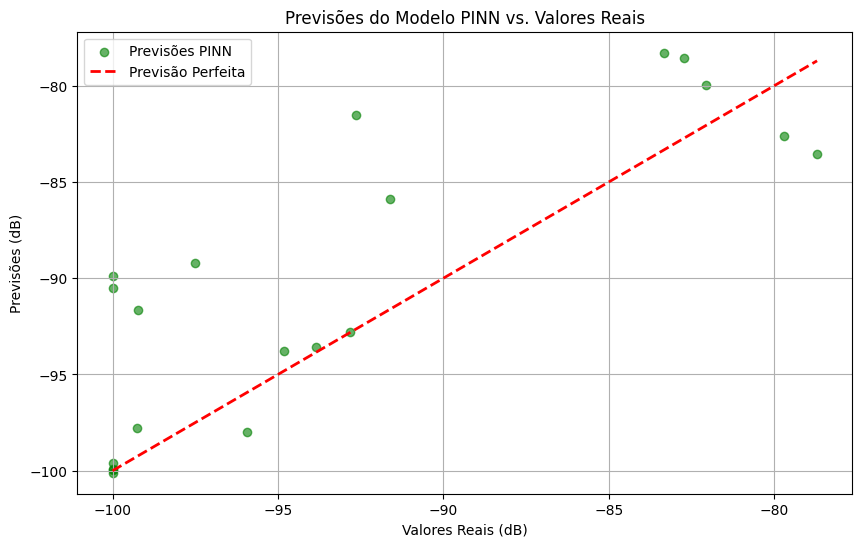

In [95]:
# ---------------------------------------------------------------------
# 5. Avaliar o Modelo PINN e Comparar
# ---------------------------------------------------------------------
# Fazer previsões (a rede só precisa da entrada normalizada para prever)
# Como o modelo tem uma entrada de dicionário, passamos os dados de teste da mesma forma
pinn_predictions_scaled = pinn_model.predict({"model_input": X_test_scaled, "physics_input": X_test})

# Desnormalizar as previsões
pinn_predictions_db = scaler_y.inverse_transform(pinn_predictions_scaled)

# Calcular o MAE
mae_pinn = mean_absolute_error(y_test, pinn_predictions_db)

print(f"\n--- Performance do Modelo PINN ---")
print(f"Erro Absoluto Médio (MAE) no conjunto de teste: {mae_pinn:.2f} dB")

print("\n--- Comparação Final ---")
print(f"MAE Baseline: {mae_baseline:.2f} dB") # mae_baseline foi calculado no Objetivo 1
print(f"MAE PINN:     {mae_pinn:.2f} dB")

if mae_pinn < mae_baseline:
    print("\nO modelo PINN superou o modelo de base! (Erro menor)")
else:
    print("\nO modelo PINN não superou o modelo de base. Tente ajustar o gamma ou treinar por mais épocas.")

# Visualizar as previsões do PINN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pinn_predictions_db, alpha=0.6, color='green', label='Previsões PINN')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Previsão Perfeita')
plt.title('Previsões do Modelo PINN vs. Valores Reais')
plt.xlabel('Valores Reais (dB)')
plt.ylabel('Previsões (dB)')
plt.legend()
plt.grid(True)
plt.show()